# Chapter 3 Tutorial: Mathematical Framework of Statistics, Part I

This notebook turns the core ideas of Chapter 3 into executable examples.

The examples follow the chapter's sequence:

1. Probability distributions
2. Cumulative distributions
3. Expected value
4. Variance, standard deviation, and coefficient of variation
5. Population vs sample
6. Random sampling and sampling fluctuation
7. Sample estimates
8. Histograms
9. Normal distribution, standardization, and quantiles
10. Covariance and correlation

The context is physical/chemical measurement, but we will use simple Python examples first.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

pd.set_option("display.precision", 4)

## 1. Discrete probability distribution

A random variable is a quantity whose value is subject to chance.

For two fair dice, the random variable is:

$$
X = \text{sum of the two dice}
$$

Possible values are:

$$
2,3,4,\ldots,12
$$

The probability distribution assigns a probability to each possible value.

In [2]:
# All outcomes from two dice
outcomes = [(a, b) for a in range(1, 7) for b in range(1, 7)]
sums = np.array([a + b for a, b in outcomes])

values, counts = np.unique(sums, return_counts=True)
probs = counts / counts.sum()

dice_dist = pd.DataFrame({
    "x": values,
    "count": counts,
    "p": probs,
    "F(x)": np.cumsum(probs)
})

dice_dist

,x,count,p,F(x)
0,2,1,0.0278,0.0278
1,3,2,0.0556,0.0833
2,4,3,0.0833,0.1667
3,5,4,0.1111,0.2778
4,6,5,0.1389,0.4167
5,7,6,0.1667,0.5833
6,8,5,0.1389,0.7222
7,9,4,0.1111,0.8333
8,10,3,0.0833,0.9167
9,11,2,0.0556,0.9722


### Interpretation

The sum 7 has the largest probability because there are many ways to make 7:

$$
(1,6),(2,5),(3,4),(4,3),(5,2),(6,1)
$$

The sum 2 has only one way:

$$
(1,1)
$$

So:

$$
P(X=7)=6/36
$$

but:

$$
P(X=2)=1/36
$$

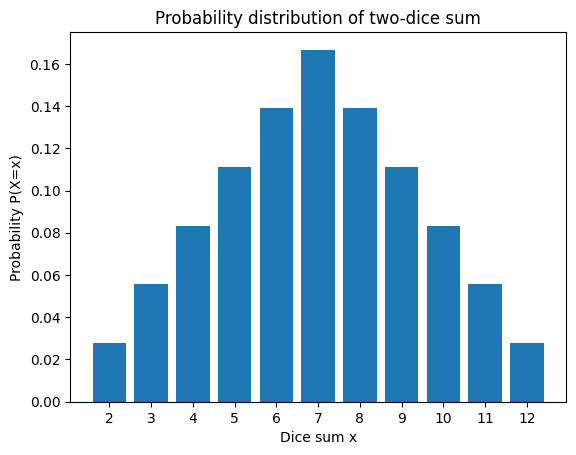

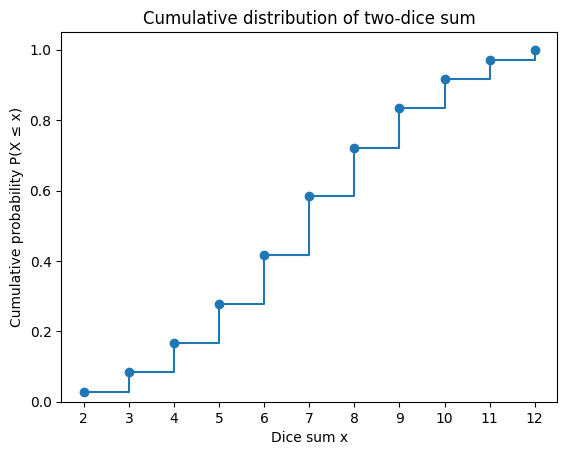

In [3]:
plt.figure()
plt.bar(dice_dist["x"], dice_dist["p"], width=0.8)
plt.xlabel("Dice sum x")
plt.ylabel("Probability P(X=x)")
plt.title("Probability distribution of two-dice sum")
plt.xticks(dice_dist["x"])
plt.show()

plt.figure()
plt.step(dice_dist["x"], dice_dist["F(x)"], where="post")
plt.scatter(dice_dist["x"], dice_dist["F(x)"])
plt.xlabel("Dice sum x")
plt.ylabel("Cumulative probability P(X ≤ x)")
plt.title("Cumulative distribution of two-dice sum")
plt.xticks(dice_dist["x"])
plt.ylim(0, 1.05)
plt.show()

## 2. Cumulative probability

The probability distribution answers:

$$
P(X=x)
$$

The cumulative distribution answers:

$$
P(X \le x)
$$

Example:

$$
P(X \le 5)=P(2)+P(3)+P(4)+P(5)
$$

In [4]:
p_le_5 = dice_dist.loc[dice_dist["x"] <= 5, "p"].sum()
p_le_5

np.float64(0.2777777777777778)

The answer is:

$$
P(X \le 5) = 10/36 \approx 0.2778
$$

## 3. Expected value

The expected value is the probability-weighted average.

For a discrete random variable:

$$
E(X)=\sum_i x_i p_i
$$

For the dice sum, this gives the long-run average sum from many throws.

In [5]:
E_dice = np.sum(dice_dist["x"] * dice_dist["p"])
E_dice

np.float64(6.999999999999998)

The expected value is 7.

This does **not** mean every throw gives 7. It means that over many repeated throws, the average approaches 7.

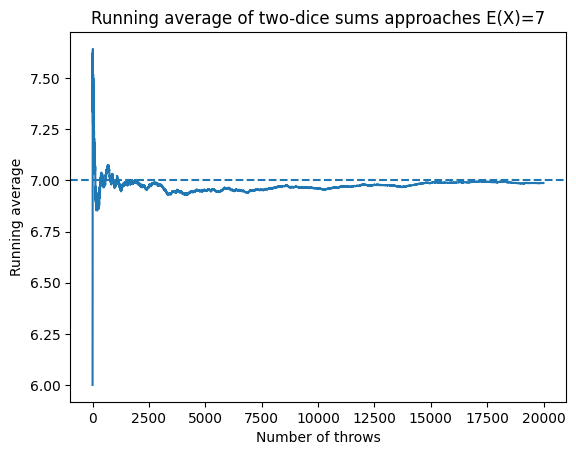

In [6]:
# Simulate repeated dice throws and show convergence of the average
n = 20_000
throws = rng.integers(1, 7, size=(n, 2)).sum(axis=1)
running_mean = np.cumsum(throws) / np.arange(1, n + 1)

plt.figure()
plt.plot(running_mean)
plt.axhline(E_dice, linestyle="--")
plt.xlabel("Number of throws")
plt.ylabel("Running average")
plt.title("Running average of two-dice sums approaches E(X)=7")
plt.show()

## 4. Skewed distribution: defective items

Suppose a lot has 10% defective items.

Take a sample of 10 items. Let:

$$
X = \text{number of defective items in the sample}
$$

If the lot is large enough, this is approximately:

$$
X \sim \mathrm{Binomial}(n=10,p=0.1)
$$

The possible values are 0, 1, 2, ..., 10.

In [7]:
from math import comb

n_items = 10
p_def = 0.1

x = np.arange(n_items + 1)
p = np.array([comb(n_items, k) * (p_def ** k) * ((1 - p_def) ** (n_items - k)) for k in x])
F = np.cumsum(p)

defect_dist = pd.DataFrame({"x_defectives": x, "p": p, "F(x)": F})
defect_dist

,x_defectives,p,F(x)
0,0,3.4868e-01,0.3487
1,1,3.8742e-01,0.7361
2,2,1.9371e-01,0.9298
3,3,5.7396e-02,0.9872
4,4,1.1160e-02,0.9984
5,5,1.4880e-03,0.9999
6,6,1.3778e-04,1.0000
7,7,8.7480e-06,1.0000
8,8,3.6450e-07,1.0000
9,9,9.0000e-09,1.0000


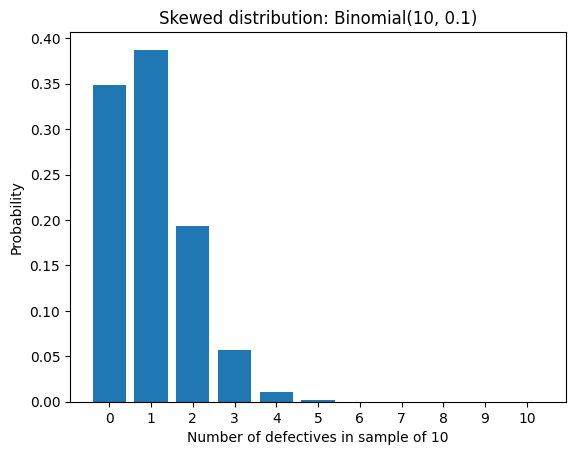

In [8]:
plt.figure()
plt.bar(defect_dist["x_defectives"], defect_dist["p"], width=0.8)
plt.xlabel("Number of defectives in sample of 10")
plt.ylabel("Probability")
plt.title("Skewed distribution: Binomial(10, 0.1)")
plt.xticks(defect_dist["x_defectives"])
plt.show()

### Interpretation

The expected number of defectives is:

$$
E(X)=np=10(0.1)=1
$$

But the distribution is not symmetric. Values above 1 are possible up to 10, while values below 1 are only 0.

This is why the mean is not always visually central.

In [9]:
E_def = np.sum(x * p)
E_def

np.float64(1.0000000000000004)

## 5. Variance and standard deviation

The variance measures spread around the mean:

$$
V(X)=E[(X-E(X))^2]
$$

For discrete variables:

$$
V(X)=\sum_i (x_i-\mu)^2p_i
$$

The standard deviation is:

$$
\sigma = \sqrt{V(X)}
$$

In [10]:
var_dice = np.sum((dice_dist["x"] - E_dice) ** 2 * dice_dist["p"])
sd_dice = math.sqrt(var_dice)

var_def = np.sum((x - E_def) ** 2 * p)
sd_def = math.sqrt(var_def)

pd.DataFrame({
    "distribution": ["two dice", "defectives Binomial(10, 0.1)"],
    "mean": [E_dice, E_def],
    "variance": [var_dice, var_def],
    "standard_deviation": [sd_dice, sd_def],
    "CV_percent": [100 * sd_dice / E_dice, 100 * sd_def / E_def]
})

,distribution,mean,variance,standard_deviation,CV_percent
0,two dice,7.0,5.8333,2.4152,34.5033
1,"defectives Binomial(10, 0.1)",1.0,0.9000,0.9487,94.8683


### Interpretation

For the defective-item example:

$$
V(X)=np(1-p)=10(0.1)(0.9)=0.9
$$

$$
\sigma=\sqrt{0.9}\approx 0.949
$$

The coefficient of variation is:

$$
\%CV = 100\frac{\sigma}{\mu}
$$

For this example:

$$
\%CV \approx 94.9\%
$$

That looks large because the mean number of defectives is only 1.

## 6. Continuous probability distribution

For a continuous variable, probability is area under a density curve.

Important distinction:

$$
f(x) \neq P(X=x)
$$

For continuous $X$:

$$
P(X=x)=0
$$

Instead:

$$
P(a \le X \le b)=\int_a^b f(x)\,dx
$$

The chapter gives an exponential-type density:

$$
f(x)=\frac{1}{k}e^{-x/k}, \quad x \ge 0
$$

This is common for waiting times, decay times, or time between random arrivals.

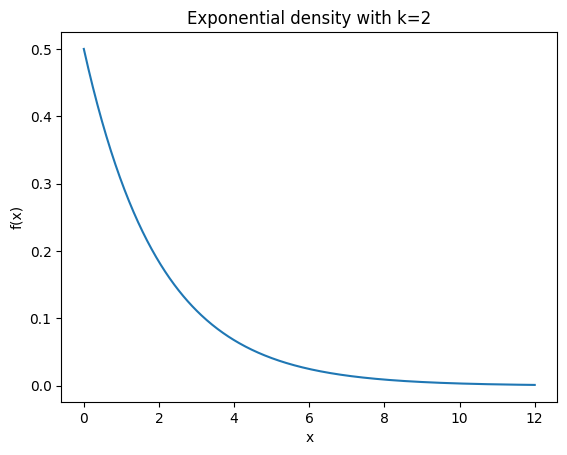

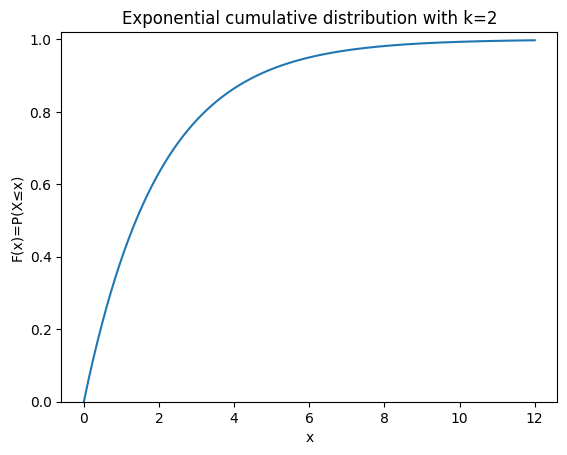

In [11]:
k = 2.0
xs = np.linspace(0, 12, 500)
pdf = (1 / k) * np.exp(-xs / k)
cdf = 1 - np.exp(-xs / k)

plt.figure()
plt.plot(xs, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Exponential density with k=2")
plt.show()

plt.figure()
plt.plot(xs, cdf)
plt.xlabel("x")
plt.ylabel("F(x)=P(X≤x)")
plt.title("Exponential cumulative distribution with k=2")
plt.ylim(0, 1.02)
plt.show()

For the exponential distribution:

$$
E(X)=k
$$

So with $k=2$, the mean waiting time is 2 units.

In [12]:
sample_exp = rng.exponential(scale=k, size=100_000)
sample_exp.mean(), sample_exp.var()

(np.float64(2.007810405766738), np.float64(4.04913388162354))

The theoretical values are:

$$
E(X)=k=2
$$

$$
V(X)=k^2=4
$$

The simulated values should be close.

## 7. Population vs sample

A population is the full set of possible values.

A sample is the finite set of values we actually observe.

For measurement work, the population is often hypothetical. For example, if we repeatedly measure the sulfur content of the same kind of rubber, the "population" is the conceptual infinite set of all measurements we could get under the same procedure.

Now simulate a physical/chemical measurement:

$$
X = \text{measured concentration}
$$

Assume the true measurement population has:

$$
\mu=100.0
$$

$$
\sigma=1.5
$$

One sample of 8 measurements is only an imperfect image of that population.

In [13]:
true_mu = 100.0
true_sigma = 1.5

sample = rng.normal(loc=true_mu, scale=true_sigma, size=8)
sample

array([ 99.91247199, 100.28556946,  99.15398593, 100.56019048,
        95.97472645, 100.40720554, 100.27276614, 102.31251033])

In [14]:
sample_mean = sample.mean()
sample_sd = sample.std(ddof=1)

sample_mean, sample_sd

(np.float64(99.85992828905542), np.float64(1.802876767156454))

The sample mean and sample standard deviation are estimates. They are not exactly equal to the true population parameters.

## 8. Sampling fluctuation

Even if the true population is fixed, different random samples give different estimates.

Let's take many samples of size 8 from the same measurement population and compute the sample mean each time.

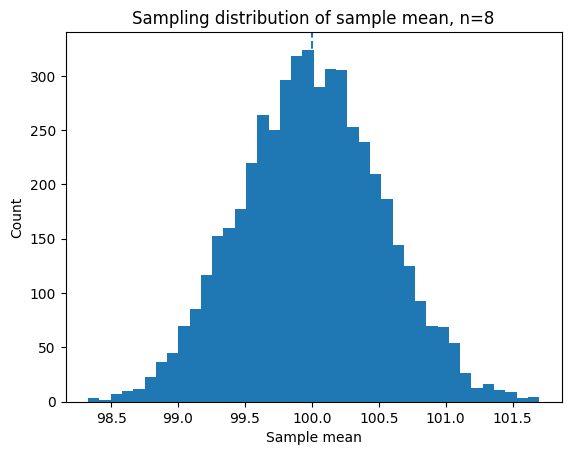

(np.float64(99.99929056330511), np.float64(0.5286207789760669))

In [15]:
n_samples = 5000
sample_size = 8

sample_means = rng.normal(loc=true_mu, scale=true_sigma, size=(n_samples, sample_size)).mean(axis=1)

plt.figure()
plt.hist(sample_means, bins=40)
plt.axvline(true_mu, linestyle="--")
plt.xlabel("Sample mean")
plt.ylabel("Count")
plt.title("Sampling distribution of sample mean, n=8")
plt.show()

sample_means.mean(), sample_means.std(ddof=1)

The standard deviation of the sample means is called the **standard error**:

$$
\sigma_{\bar X}=\frac{\sigma}{\sqrt{N}}
$$

For $N=8$:

$$
\sigma_{\bar X}=\frac{1.5}{\sqrt{8}}
$$

In [16]:
true_sigma / math.sqrt(sample_size)

0.5303300858899106

## 9. Sample variance uses $N-1$

For a sample:

$$
s^2=\frac{\sum_i (x_i-\bar{x})^2}{N-1}
$$

The denominator is $N-1$, not $N$, because the residuals must sum to zero:

$$
\sum_i (x_i-\bar{x})=0
$$

Once $N-1$ residuals are known, the last one is determined.

In [17]:
residuals = sample - sample.mean()
pd.DataFrame({"x": sample, "x - xbar": residuals})

,x,x - xbar
0,99.9125,0.0525
1,100.2856,0.4256
2,99.1540,-0.7059
3,100.5602,0.7003
4,95.9747,-3.8852
5,100.4072,0.5473
6,100.2728,0.4128
7,102.3125,2.4526


In [18]:
residuals.sum()

np.float64(-1.4210854715202004e-14)

In [19]:
variance_with_N = np.sum(residuals**2) / len(sample)
variance_with_N_minus_1 = np.sum(residuals**2) / (len(sample) - 1)

variance_with_N, variance_with_N_minus_1

(np.float64(2.8440690578584435), np.float64(3.250364637552507))

The $N-1$ version is the usual unbiased estimate of population variance.

Important note: for a normal distribution, the maximum-likelihood estimate of variance uses denominator $N$, not $N-1$. So "sample variance" and "maximum-likelihood variance estimate" are not the same thing.

## 10. Histogram as a sample-image of a distribution

A histogram approximates the shape of the population distribution.

But a histogram from a small sample can be misleading.

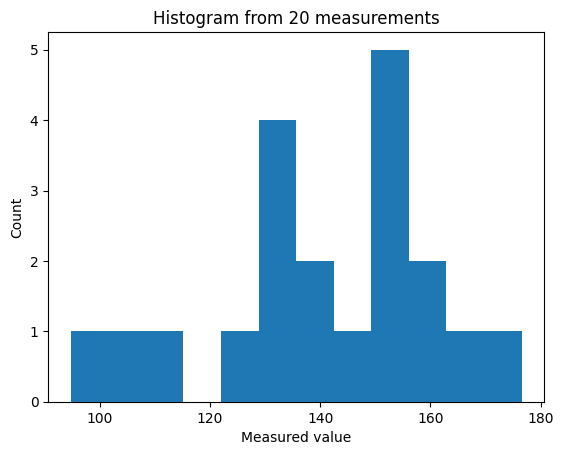

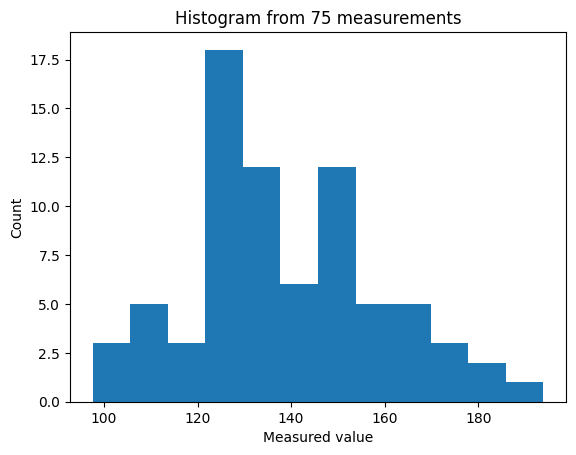

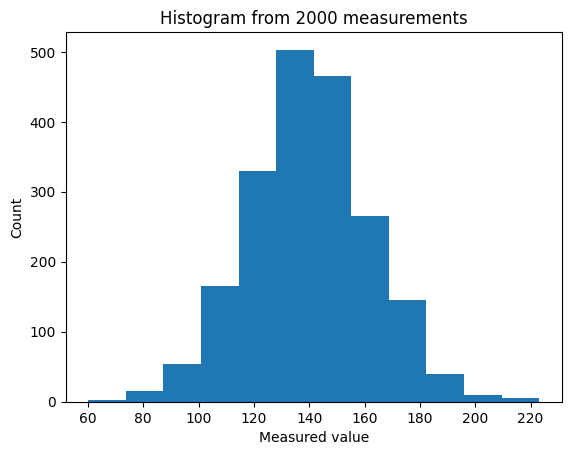

In [20]:
population = rng.normal(loc=140, scale=22, size=1_000_000)

small_sample = rng.choice(population, size=20, replace=False)
medium_sample = rng.choice(population, size=75, replace=False)
large_sample = rng.choice(population, size=2000, replace=False)

for data, title in [
    (small_sample, "Histogram from 20 measurements"),
    (medium_sample, "Histogram from 75 measurements"),
    (large_sample, "Histogram from 2000 measurements"),
]:
    plt.figure()
    plt.hist(data, bins=12)
    plt.xlabel("Measured value")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

### Interpretation

The chapter's Sheffield smoothness example uses 75 paper smoothness measurements.

Material-science context: paper smoothness affects printing and coating behavior. The measured smoothness values vary because of material variation, instrument variation, operator variation, and lab-to-lab differences.

A histogram gives a rough picture of the distribution, but even 75 observations can leave uncertainty about symmetry, skewness, or outliers.

## 11. Order-statistic-like example: gap between largest and second-largest

The chapter constructs a new variable:

$$
G = \text{largest value in a group of 5} - \text{second-largest value in the group}
$$

This distribution is skewed. Small gaps are common; large gaps are rare.

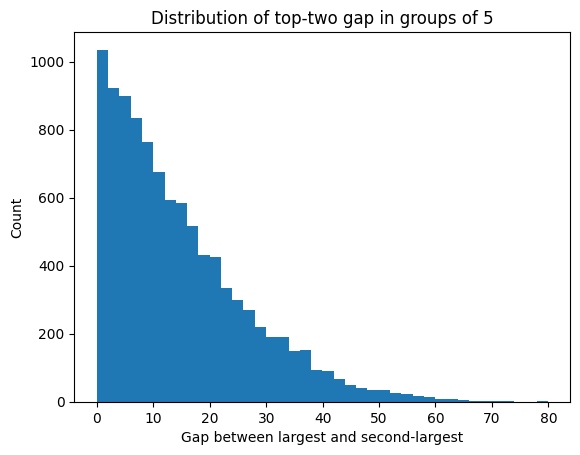

count    10000.0000
mean        14.6274
std         12.0864
min          0.0002
25%          5.2195
50%         11.6410
75%         21.1494
max         79.9189
dtype: float64

In [21]:
groups = rng.normal(loc=140, scale=22, size=(10_000, 5))
sorted_groups = np.sort(groups, axis=1)
gaps = sorted_groups[:, -1] - sorted_groups[:, -2]

plt.figure()
plt.hist(gaps, bins=40)
plt.xlabel("Gap between largest and second-largest")
plt.ylabel("Count")
plt.title("Distribution of top-two gap in groups of 5")
plt.show()

pd.Series(gaps).describe()

This explains why the chapter's second histogram is skewed. It is not a distribution of raw measurements; it is a distribution of a derived statistic.

## 12. Normal distribution

The normal distribution is:

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-(x-\mu)^2/(2\sigma^2)}
$$

It is determined by:

- mean $\mu$
- standard deviation $\sigma$

Many measurement errors are approximately normal because many small independent effects add together.

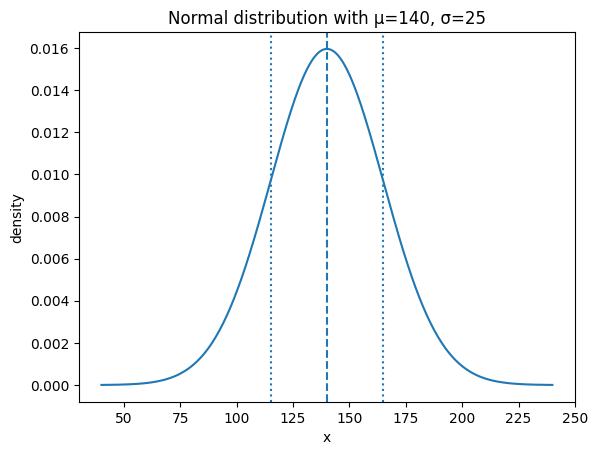

In [22]:
mu = 140
sigma = 25

xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
normal_pdf = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)

plt.figure()
plt.plot(xs, normal_pdf)
plt.axvline(mu, linestyle="--")
plt.axvline(mu - sigma, linestyle=":")
plt.axvline(mu + sigma, linestyle=":")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Normal distribution with μ=140, σ=25")
plt.show()

## 13. Standardization

Any normal variable can be converted to a standard normal variable:

$$
Z=\frac{X-\mu}{\sigma}
$$

Example from the chapter:

$$
\mu=140,\quad \sigma=25
$$

Find:

$$
P(160 \le X \le 170)
$$

Convert endpoints:

$$
z_1=\frac{160-140}{25}=0.8
$$

$$
z_2=\frac{170-140}{25}=1.2
$$

In [23]:
import statistics

normal = statistics.NormalDist(mu=140, sigma=25)
standard_normal = statistics.NormalDist(mu=0, sigma=1)

prob_x = normal.cdf(170) - normal.cdf(160)
prob_z = standard_normal.cdf(1.2) - standard_normal.cdf(0.8)

prob_x, prob_z

(0.09678572836168853, 0.09678572836168842)

The two probabilities are the same because standardization only changes scale.

## 14. Quantiles and percentiles

A $p$-quantile is the value \(x\) such that:

$$
P(X \le x)=p
$$

For the standard normal distribution, the 0.99 quantile is about 2.326.

In [24]:
for p in [0.01, 0.05, 0.20, 0.50, 0.80, 0.95, 0.99]:
    print(p, standard_normal.inv_cdf(p))

0.01 -2.3263478740408408
0.05 -1.6448536269514726
0.2 -0.8416212335729142
0.5 0.0
0.8 0.8416212335729144
0.95 1.6448536269514715
0.99 2.3263478740408408


Interpretation:

$$
P(Z \le 2.326) = 0.99
$$

So only about 1% of standard normal values exceed 2.326.

## 15. Covariance and correlation

Covariance measures whether two variables tend to deviate from their means together:

$$
\mathrm{Cov}(X,Y)=E[(X-E(X))(Y-E(Y))]
$$

Correlation standardizes covariance:

$$
\rho(X,Y)=\frac{\mathrm{Cov}(X,Y)}{\sigma_X\sigma_Y}
$$

Correlation is unitless and lies between -1 and 1.

In [25]:
# Independent random variables
x = rng.normal(0, 1, size=500)
y_ind = rng.normal(0, 1, size=500)

# Positively associated variables
y_pos = 2*x + rng.normal(0, 0.7, size=500)

# Negatively associated variables
y_neg = -2*x + rng.normal(0, 0.7, size=500)

def cov_corr(a, b):
    return {
        "covariance": np.cov(a, b, ddof=1)[0, 1],
        "correlation": np.corrcoef(a, b)[0, 1],
    }

pd.DataFrame({
    "independent": cov_corr(x, y_ind),
    "positive association": cov_corr(x, y_pos),
    "negative association": cov_corr(x, y_neg),
})

,independent,positive association,negative association
covariance,-0.0143,2.0504,-2.0693
correlation,-0.0140,0.9443,-0.9481


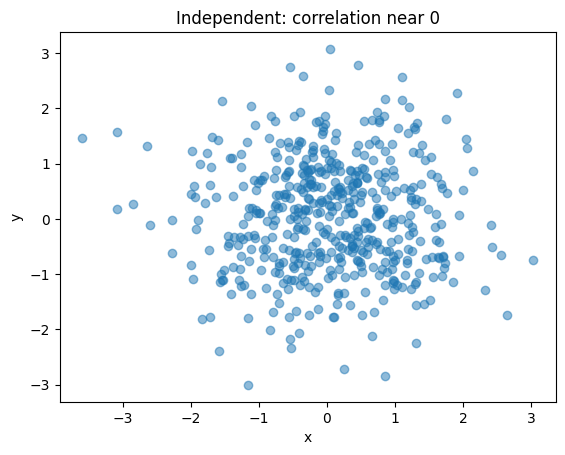

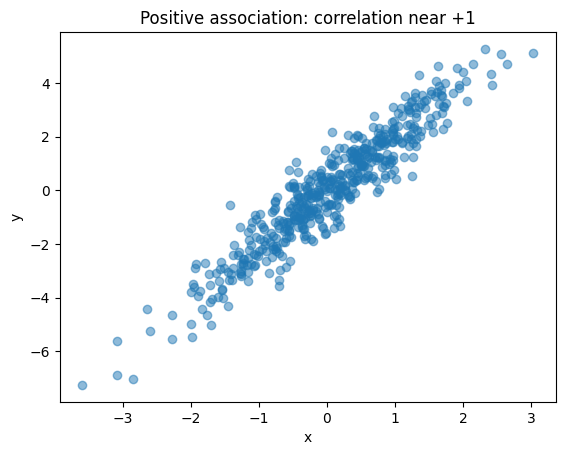

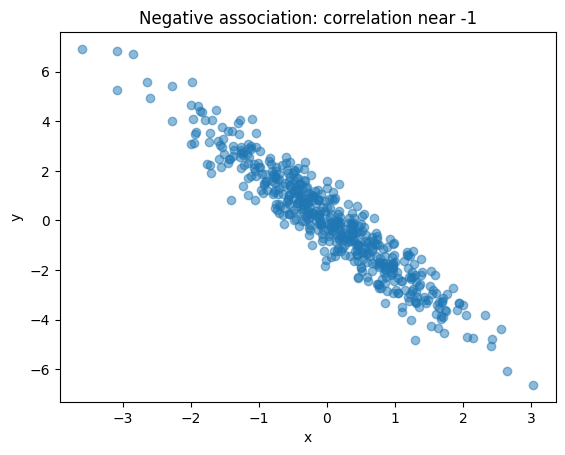

In [26]:
for y, title in [
    (y_ind, "Independent: correlation near 0"),
    (y_pos, "Positive association: correlation near +1"),
    (y_neg, "Negative association: correlation near -1"),
]:
    plt.figure()
    plt.scatter(x, y, alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()

## 16. Functional dependence vs statistical dependence

The chapter emphasizes a subtle distinction.

Example: ball bearings.

True weight is functionally related to true diameter:

$$
W = C d^3
$$

because the volume of a sphere is:

$$
V=\frac{\pi}{6}d^3
$$

and mass/weight is proportional to volume times density.

But the **measurement errors** in diameter and weight may be statistically independent.

Modern measurement model:

$$
d_{\text{obs}} = d_{\text{true}} + \epsilon_d
$$

$$
w_{\text{obs}} = w_{\text{true}} + \epsilon_w
$$

The true quantities are functionally related, but the errors \(\epsilon_d\) and \(\epsilon_w\) may be independent.

## 17. Important cautions about Chapter 3 definitions

### Probability distribution vs frequency distribution

The chapter sometimes treats these as nearly interchangeable.

Modern distinction:

- probability distribution: theoretical probabilities
- frequency distribution: observed counts/frequencies in data

### Density is not probability

For continuous variables, $f(x)$ is a density, not a probability.

$$
P(X=x)=0
$$

Probability comes from area:

$$
P(a\le X\le b)=\int_a^b f(x)\,dx
$$

### Variance is not always the "best" spread measure

Variance is mathematically convenient, but alternatives can be better when data are skewed or have outliers:

- median absolute deviation
- interquartile range
- trimmed standard deviation

### Zero correlation does not imply independence

Independence implies zero correlation when variances exist.

But zero correlation does not always imply independence.

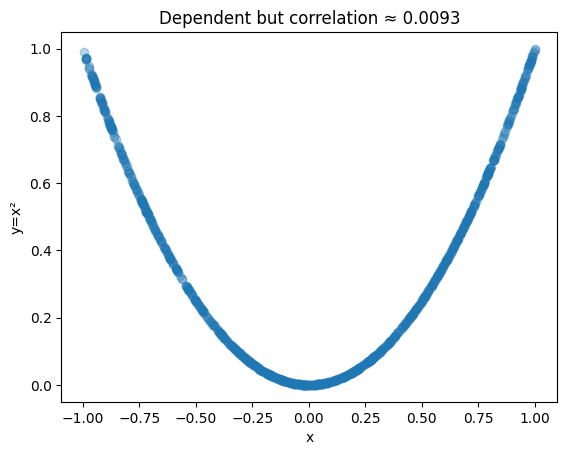

np.float64(0.009318907592319426)

In [27]:
# Zero correlation but not independent example
x = rng.uniform(-1, 1, size=10_000)
y = x**2

corr = np.corrcoef(x, y)[0, 1]

plt.figure()
plt.scatter(x[:1000], y[:1000], alpha=0.3)
plt.xlabel("x")
plt.ylabel("y=x²")
plt.title(f"Dependent but correlation ≈ {corr:.4f}")
plt.show()

corr

Here $Y=X^2$, so $Y$ is completely determined by $X$. They are clearly dependent.

But the correlation is near zero because the relationship is nonlinear and symmetric.

## 18. Final checklist

After Chapter 3, you should be able to answer:

1. What is the random variable?
2. What is its population distribution?
3. What sample did we observe?
4. What is the sample mean?
5. What is the sample variance and standard deviation?
6. What is the coefficient of variation?
7. What does the histogram suggest?
8. Is the distribution symmetric or skewed?
9. Can normal approximation be justified?
10. Are two variables independent, correlated, or functionally related?
11. Are we talking about true population parameters or sample estimates?

These questions are the bridge from raw measurement data to statistical inference.